Sube tus archivos .txt extraídos de OpenSignals: 



<>:77: SyntaxWarning: invalid escape sequence '\m'
<>:84: SyntaxWarning: invalid escape sequence '\m'
<>:92: SyntaxWarning: invalid escape sequence '\m'
<>:100: SyntaxWarning: invalid escape sequence '\m'
<>:77: SyntaxWarning: invalid escape sequence '\m'
<>:84: SyntaxWarning: invalid escape sequence '\m'
<>:92: SyntaxWarning: invalid escape sequence '\m'
<>:100: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1695/3265543668.py:77: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("Amplitud ($\mu$V)")
/tmp/ipykernel_1695/3265543668.py:84: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("Amplitud ($\mu$V)")
/tmp/ipykernel_1695/3265543668.py:92: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("Amplitud ($\mu$V)")
/tmp/ipykernel_1695/3265543668.py:100: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("Amplitud ($\mu$V)")


Saving libreprguntadificil.txt to libreprguntadificil (1).txt
Saving librepreguntafacil.txt to librepreguntafacil (2).txt
Saving basal3.txt to basal3 (2).txt
Saving artefactos.txt to artefactos (2).txt
Saving basal2.txt to basal2 (2).txt
Saving ojosfijopunto.txt to ojosfijopunto (2).txt
Saving basal1.txt to basal1 (2).txt

 Procesando y graficando: libreprguntadificil (1).txt 


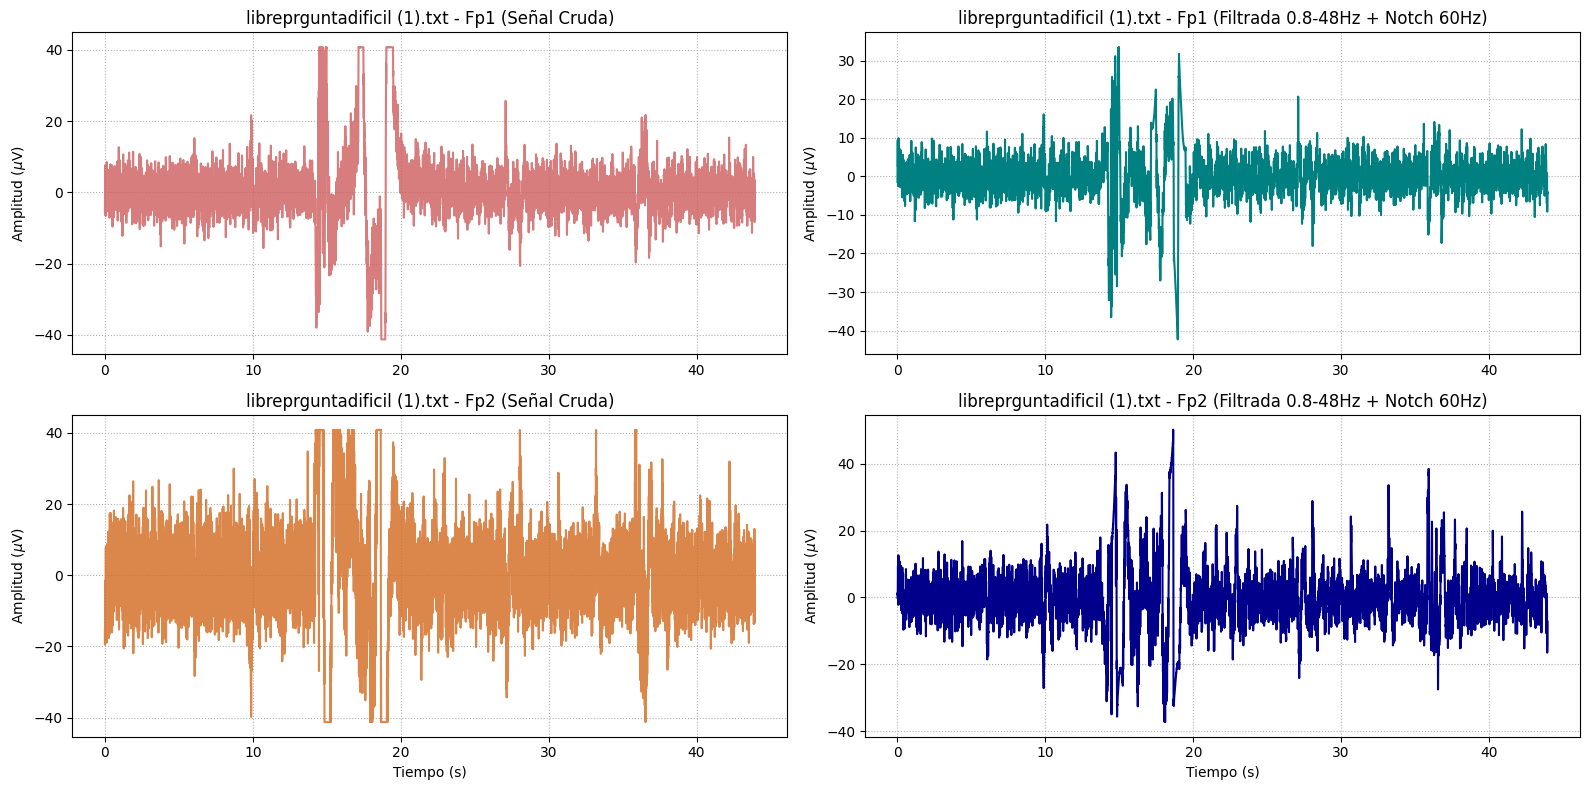


 Procesando y graficando: librepreguntafacil (2).txt 


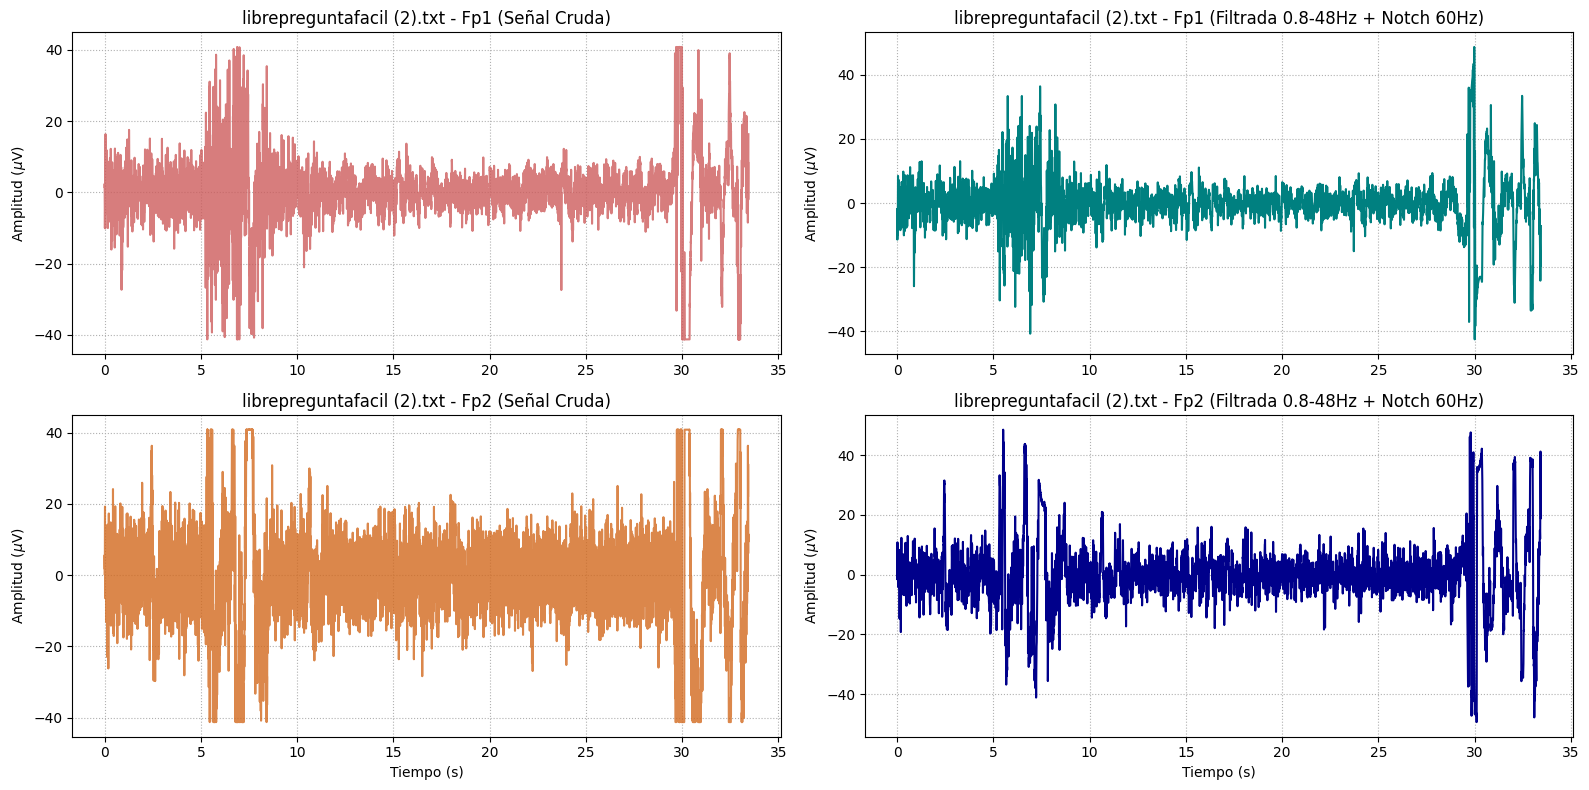


 Procesando y graficando: basal3 (2).txt 


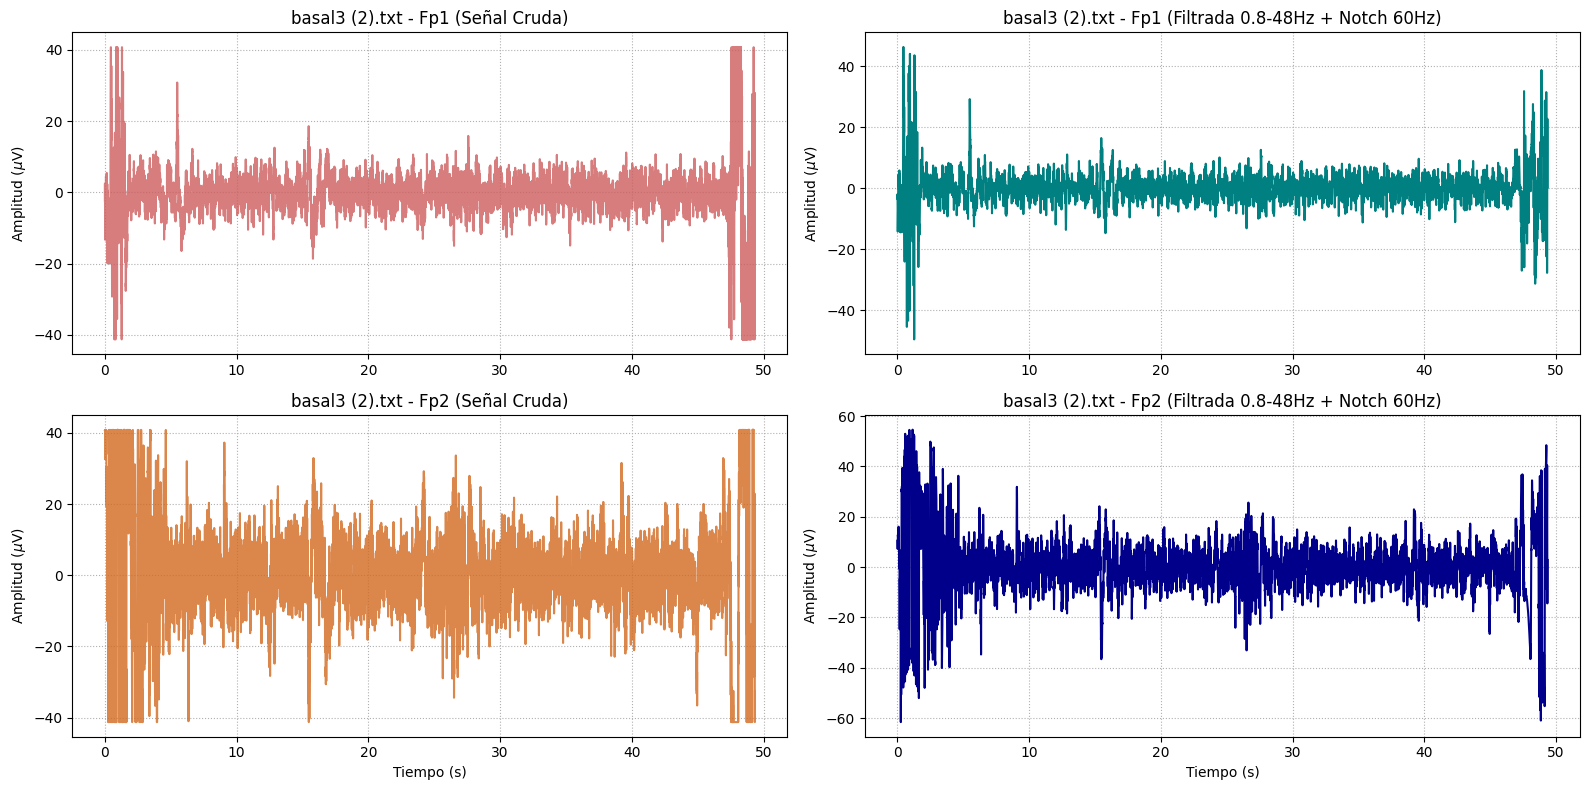


 Procesando y graficando: artefactos (2).txt 


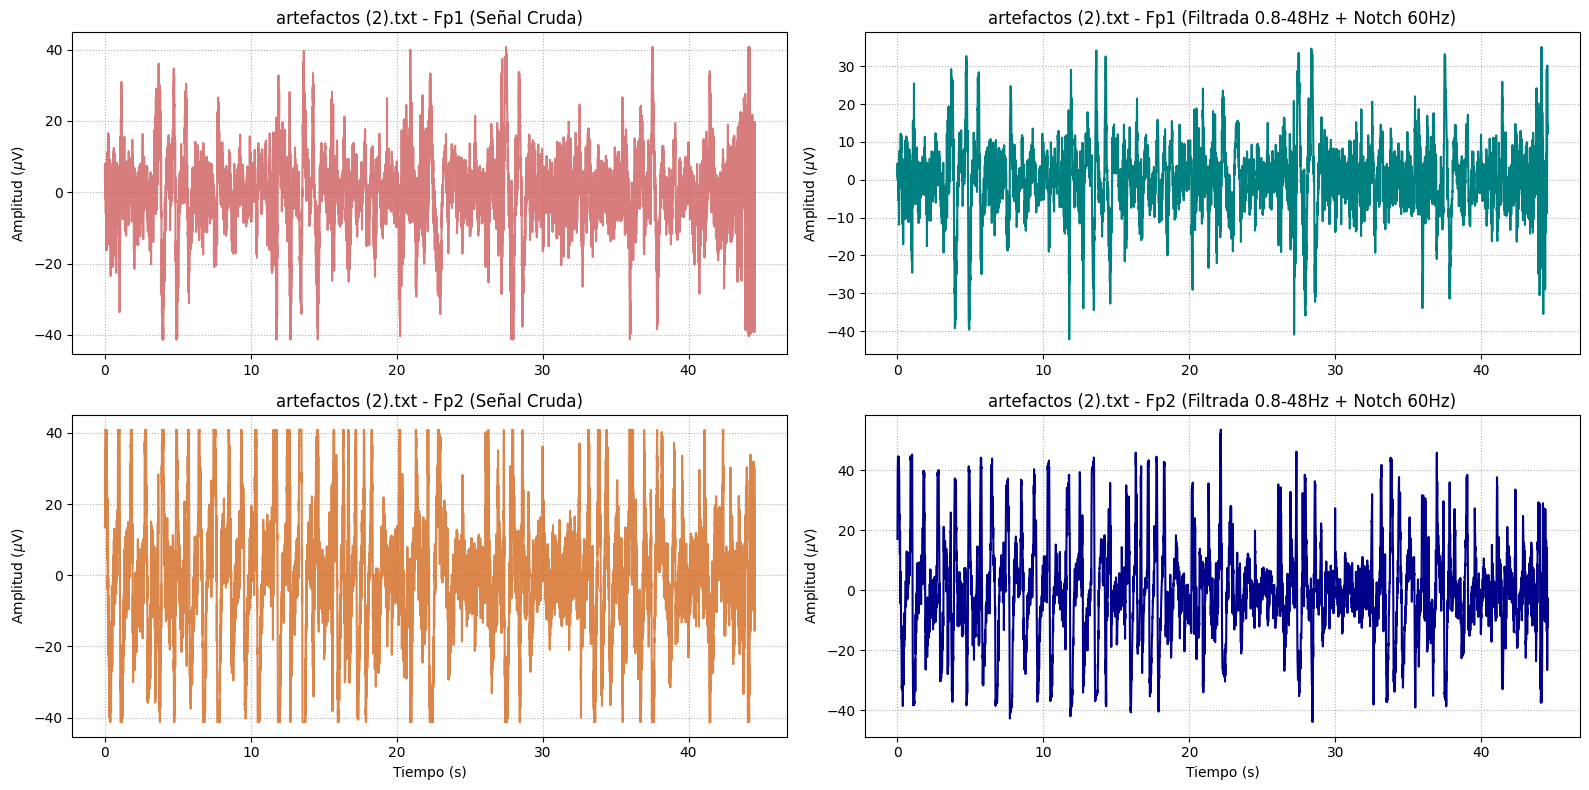


 Procesando y graficando: basal2 (2).txt 


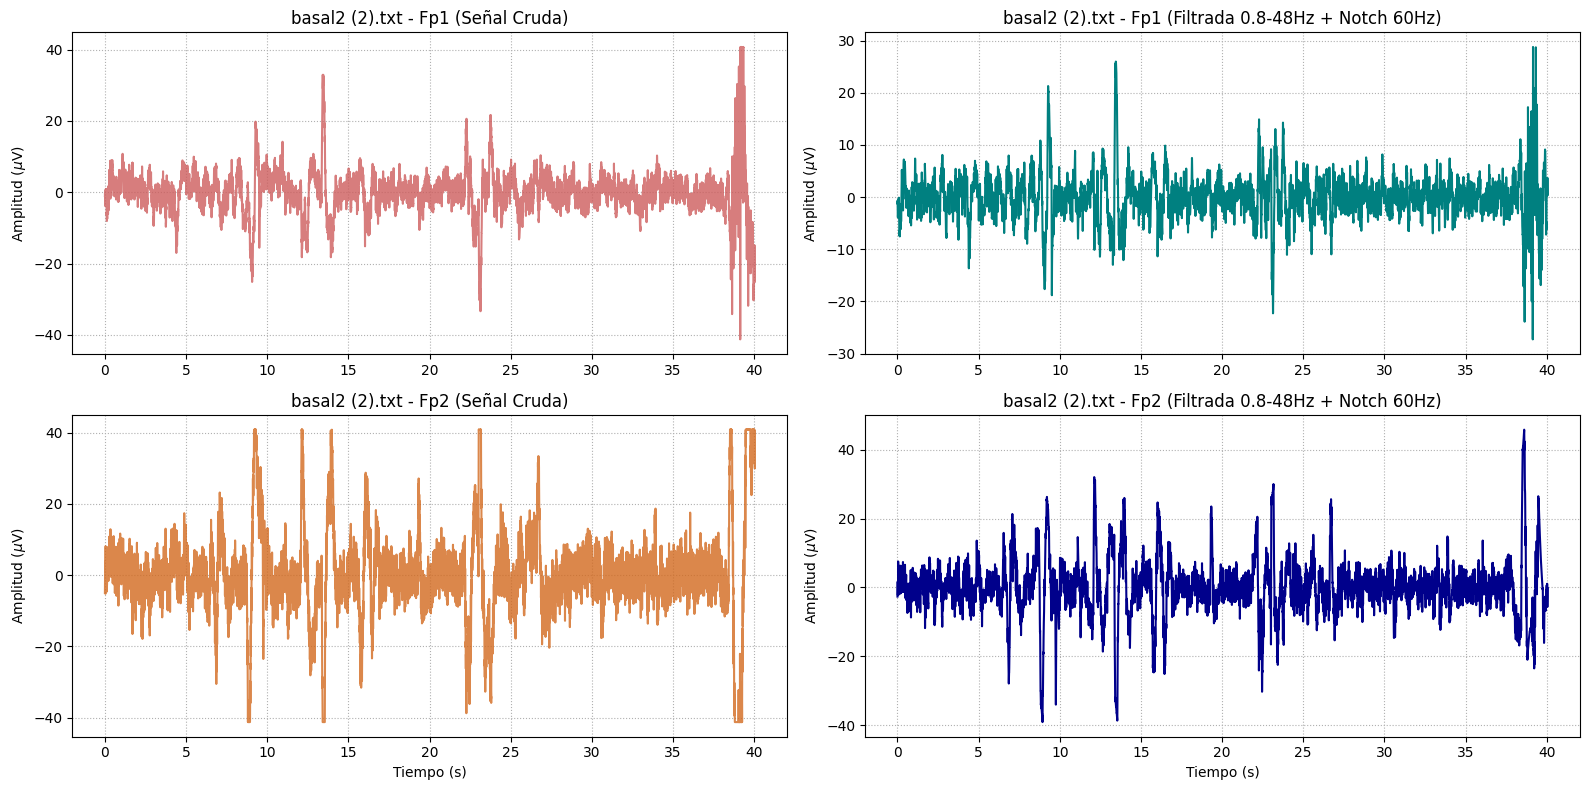


 Procesando y graficando: ojosfijopunto (2).txt 


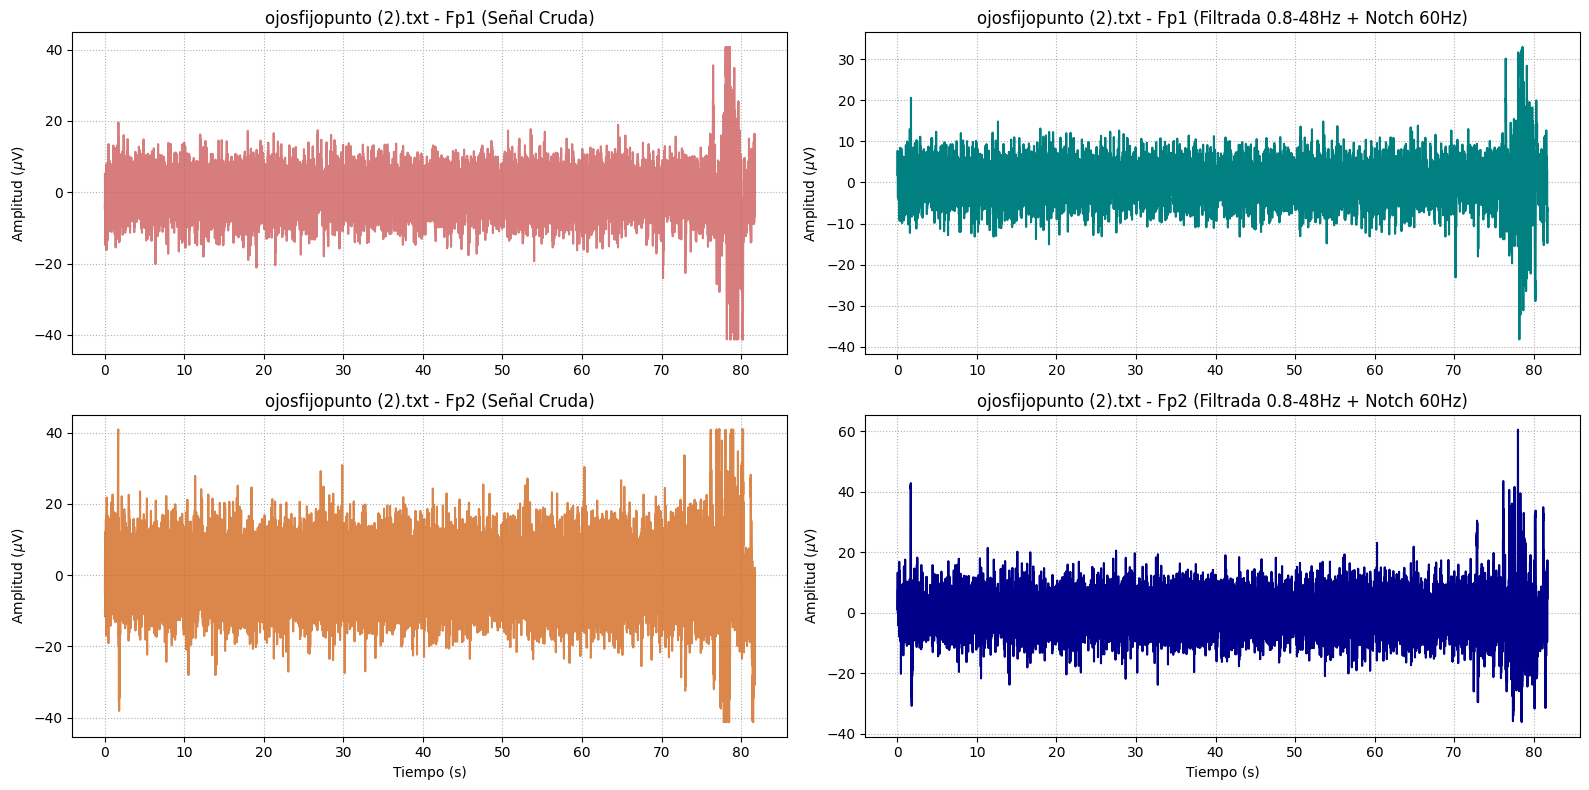


 Procesando y graficando: basal1 (2).txt 


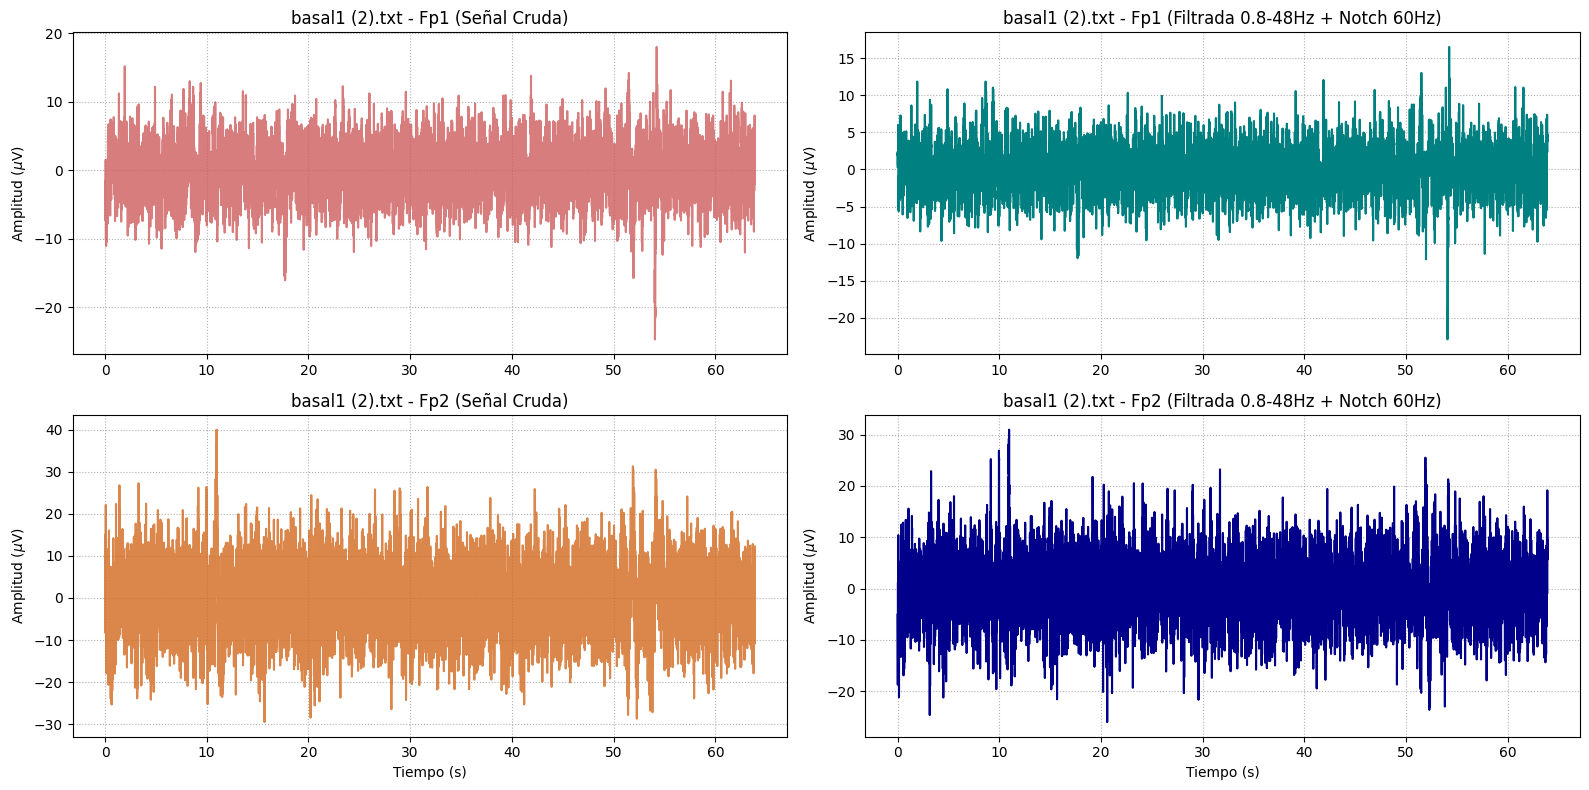

In [3]:
#PROCESAMIENTO SEÑALES LAB 7

# Importamos las librerías que usaremos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as signal
from google.colab import files #esto sirve para subir los archivos txt


#funcion conversión de señales txt eeg a microvoltios
def bitalino_eeg_to_uv(adc_data, vcc=3.3, bits=10, gain=40000):
    #Fórmula oficial de la hoja de datos del sensor EEG de BITalino
    eeg_uv = (((adc_data / (2**bits)) - 0.5) * vcc / gain) * 1e6
    return eeg_uv

fs = 1000  #Frecuencia de muestreo sugerida en la guía de laboratorio (1000 Hz)
nyq = 0.5 * fs

#----------------------------------------------------------------------------------------------

#Diseño de filtros

#Filtro Pasabanda Butterworth (0.8 - 48 Hz)
low_cut = 0.8 / nyq
high_cut = 48.0 / nyq
b_band, a_band = signal.butter(4, [low_cut, high_cut], btype='bandpass')

#Filtro Notch para ruido de la red eléctrica (60 Hz)
f0 = 60.0
Q = 30.0
b_notch, a_notch = signal.iirnotch(f0, Q, fs)

#Carga de datos en bucle
print("Sube tus archivos .txt extraídos de OpenSignals: \n")
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\n Procesando y graficando: {filename} ")

    #Leer el .txt ignorando las líneas de configuración que inician con '#'
    df = pd.read_csv(filename, sep='\t', comment='#', header=None)

    #Extraer columnas (A3 = Fp1 en índice 5) y (A4 = Fp2 en índice 6)

    #Fp1 y Fp2 son las señales capturadas en las 2 cejas, para después compararlas

    fp1_raw = df.iloc[:, 5].values
    fp2_raw = df.iloc[:, 6].values

    #Convertir a Microvoltios (conversión adc)
    fp1_uv = bitalino_eeg_to_uv(fp1_raw)
    fp2_uv = bitalino_eeg_to_uv(fp2_raw)

    N = len(fp1_uv)
    Ts = 1 / fs
    t = np.arange(N) * Ts

    #Aplicar filtros en cascada (Pasabanda -> Notch) usando filtfilt para no desfasar
    fp1_filtrada = signal.filtfilt(b_band, a_band, fp1_uv)
    fp1_filtrada = signal.filtfilt(b_notch, a_notch, fp1_filtrada)

    fp2_filtrada = signal.filtfilt(b_band, a_band, fp2_uv)
    fp2_filtrada = signal.filtfilt(b_notch, a_notch, fp2_filtrada)

    # --------------------------------------------------------------------------



    #ploteo
    plt.figure(figsize=(16, 8))

    #Subplot 1: Fp1 Cruda (Arriba Izquierda)
    plt.subplot(2, 2, 1)
    plt.plot(t, fp1_uv, color='indianred', alpha=0.8)
    plt.title(f"{filename} - Fp1 (Señal Cruda)")
    plt.ylabel("Amplitud ($\mu$V)")
    plt.grid(ls=":")

    #Subplot 2: Fp1 Filtrada (Arriba Derecha)
    plt.subplot(2, 2, 2)
    plt.plot(t, fp1_filtrada, color='teal')
    plt.title(f"{filename} - Fp1 (Filtrada 0.8-48Hz + Notch 60Hz)")
    plt.ylabel("Amplitud ($\mu$V)")
    plt.grid(ls=":")

    #Subplot 3: Fp2 Cruda (Abajo Izquierda)
    plt.subplot(2, 2, 3)
    plt.plot(t, fp2_uv, color='chocolate', alpha=0.8)
    plt.title(f"{filename} - Fp2 (Señal Cruda)")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud ($\mu$V)")
    plt.grid(ls=":")

    #Subplot 4: Fp2 Filtrada (Abajo Derecha)
    plt.subplot(2, 2, 4)
    plt.plot(t, fp2_filtrada, color='darkblue')
    plt.title(f"{filename} - Fp2 (Filtrada 0.8-48Hz + Notch 60Hz)")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Amplitud ($\mu$V)")
    plt.grid(ls=":")

    plt.tight_layout() # Evita que los textos se superpongan
    plt.show()